# Analisi di `transactions_simple_timing_train.csv`

Dataset sintetico generato dall'esperimento **`simple_timing`**: i quattro
cluster sono **identici in tutto ciò che viene embeddato come valore**
(distribuzione di `importo`, pool di `merchant`, `cocau`, volume di
transazioni) e differiscono **solo** nella firma temporale — l'ora del giorno
e il giorno della settimana in cui avvengono le transazioni.

| Cluster | Ora di picco | Giorni preferiti |
|---|---|---|
| `mattiniero_feriale` | 09 | Lun–Mar |
| `pranzo_infrasettimanale` | 13 | Mer–Gio |
| `serale_weekend` | 20 | Ven–Sab |
| `notturno_weekend` | 02 | Sab–Dom |

È un *probe* per la parte time-aware del modello. Di conseguenza l'analisi è
rovesciata rispetto a `simple_spatial`:
1. **controllo** — le variabili di valore (importo / merchant / cocau)
   devono risultare ~indistinguibili tra cluster;
2. **segnale** — le variabili temporali (ora, giorno settimana) separano i
   cluster; lo verifichiamo proiettando con **PCA** e **t-SNE** feature
   temporali aggregate per cliente, e mostrando il contrasto con le feature
   di valore.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 60)

In [2]:
def find_repo_root(start: Path) -> Path:
    """Risale le cartelle finché trova la radice del repo (data/ + config.toml)."""
    for p in [start, *start.parents]:
        if (p / "data").is_dir() and (p / "config.toml").exists():
            return p
    return start

ROOT = find_repo_root(Path.cwd())
CSV = ROOT / "data" / "transactions_simple_timing_train.csv"

# Nomi colonna canonici (src/constant.py -> DataConfig)
CLIENT, CLUSTER, TS = "client_id", "cluster", "timestamp"
AMOUNT, MERCHANT, COCAU = "importo", "merchant", "cocau"

df = pd.read_csv(CSV)
df[TS] = pd.to_datetime(df[TS], unit="s")
df = df.sort_values([CLIENT, TS]).reset_index(drop=True)
df["hour"] = df[TS].dt.hour
df["dow"] = df[TS].dt.dayofweek  # 0 = lunedì
df["delta_t_days"] = df.groupby(CLIENT)[TS].diff().dt.total_seconds() / 86400.0
print("File:", CSV)
print("Righe x colonne:", df.shape)
df.head()

File: /home/julien/Documents/python-proj/embeddingclient/data/transactions_simple_timing_train.csv
Righe x colonne: (480481, 9)


,client_id,cluster,timestamp,importo,merchant,cocau,hour,dow,delta_t_days
0,0,pranzo_infrasettimanale,2020-01-01 14:16:02,66.789813,Netflix,101,14,2,NaN
1,0,pranzo_infrasettimanale,2020-01-29 12:39:28,32.890487,Satispay,101,12,2,27.932940
2,0,pranzo_infrasettimanale,2020-02-05 16:18:09,26.430635,Conad,89,16,2,7.151863
3,0,pranzo_infrasettimanale,2020-02-11 12:18:52,66.602274,Aldi,149,12,1,5.833831
4,0,pranzo_infrasettimanale,2020-02-21 10:52:08,15.671779,Aldi,58,10,4,9.939769


## 0. Panoramica e bilanciamento dei cluster

In [3]:
df.info()
print("\nValori mancanti per colonna:")
print(df.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 480481 entries, 0 to 480480
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype        
---  ------        --------------   -----        
 0   client_id     480481 non-null  int64        
 1   cluster       480481 non-null  str          
 2   timestamp     480481 non-null  datetime64[s]
 3   importo       480481 non-null  float64      
 4   merchant      480481 non-null  str          
 5   cocau         480481 non-null  int64        
 6   hour          480481 non-null  int32        
 7   dow           480481 non-null  int32        
 8   delta_t_days  476481 non-null  float64      
dtypes: datetime64[s](1), float64(2), int32(2), int64(2), str(2)
memory usage: 29.3 MB

Valori mancanti per colonna:
client_id          0
cluster            0
timestamp          0
importo            0
merchant           0
cocau              0
hour               0
dow                0
delta_t_days    4000
dtype: int64


,n_clients,n_transactions,tx_per_client
cluster,,,
mattiniero_feriale,1000,120570,120.6
notturno_weekend,1000,120450,120.4
pranzo_infrasettimanale,1000,119307,119.3
serale_weekend,1000,120154,120.2


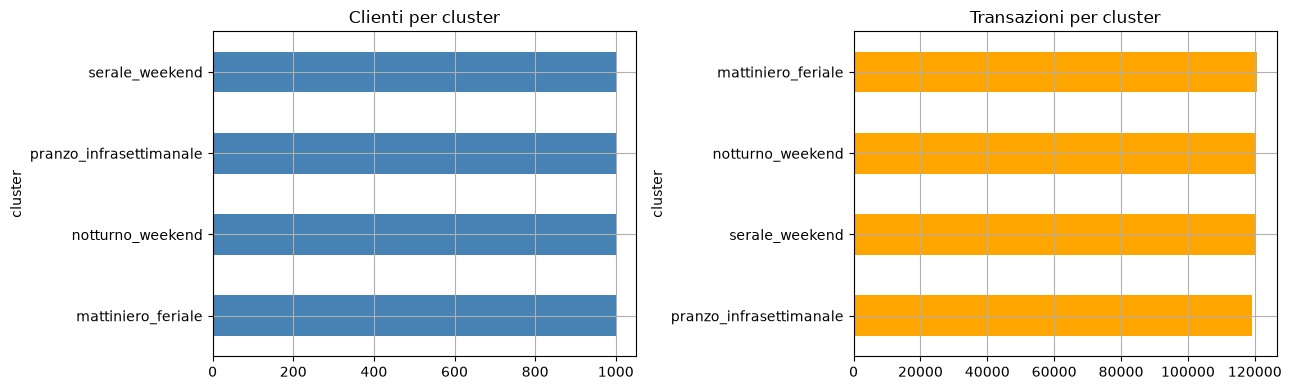

In [4]:
clusters = sorted(df[CLUSTER].unique())
n_clients = df.groupby(CLUSTER)[CLIENT].nunique()
n_tx = df[CLUSTER].value_counts()
summary = pd.DataFrame({"n_clients": n_clients, "n_transactions": n_tx})
summary["tx_per_client"] = (summary["n_transactions"] / summary["n_clients"]).round(1)
display(summary)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
n_clients.sort_values().plot.barh(ax=ax[0], color="steelblue", title="Clienti per cluster")
n_tx.sort_values().plot.barh(ax=ax[1], color="orange", title="Transazioni per cluster")
plt.tight_layout()

## 1. Controllo: le variabili di valore sono condivise

Per costruzione `importo`, `merchant` e `cocau` provengono da un unico
`SharedProfile`: ci aspettiamo distribuzioni **sovrapposte** tra i cluster.
Se così non fosse, ci sarebbe una fuga di segnale non temporale.

Statistiche di importo per cluster (attese ~uguali):


,mean,std,median
cluster,,,
mattiniero_feriale,41.84,28.83,41.91
notturno_weekend,41.77,28.83,41.79
pranzo_infrasettimanale,41.79,28.73,41.82
serale_weekend,41.76,28.88,41.67


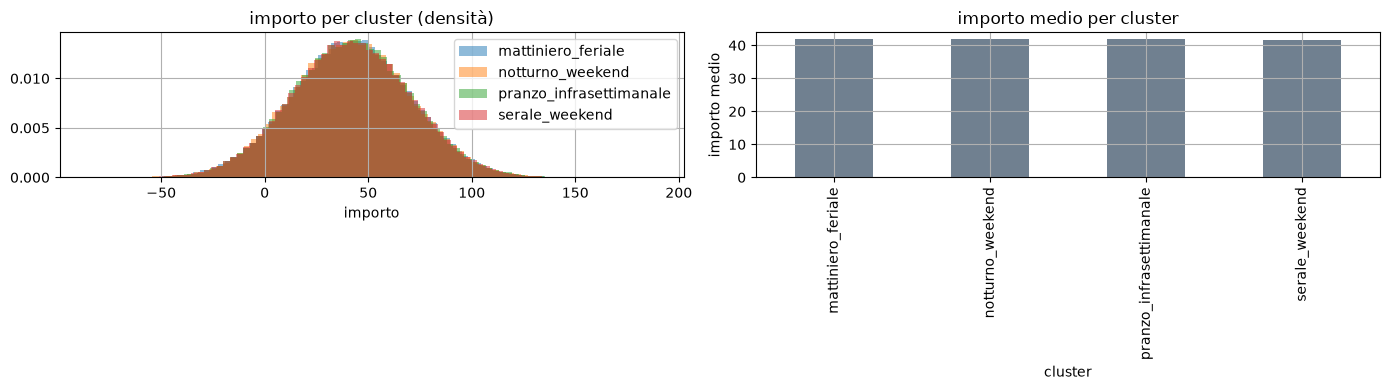

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for c in clusters:
    ax[0].hist(df.loc[df[CLUSTER] == c, AMOUNT], bins=80, alpha=0.5, density=True, label=c)
ax[0].set(title="importo per cluster (densità)", xlabel="importo")
ax[0].legend()
df.groupby(CLUSTER)[AMOUNT].mean().plot.bar(ax=ax[1], color="slategray", title="importo medio per cluster")
ax[1].set_ylabel("importo medio")
plt.tight_layout()

print("Statistiche di importo per cluster (attese ~uguali):")
df.groupby(CLUSTER)[AMOUNT].agg(["mean", "std", "median"]).round(2)

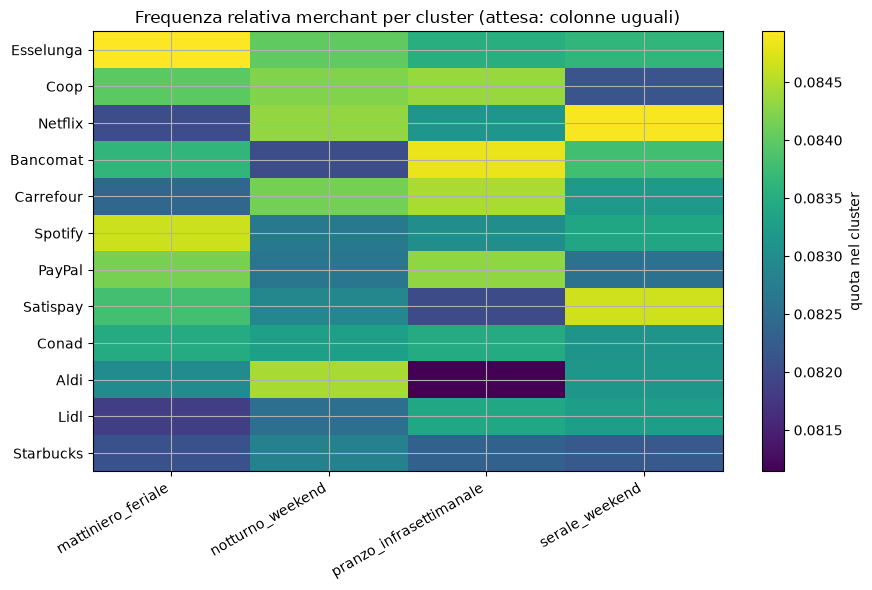

In [6]:
# Frequenza relativa dei merchant per cluster: colonne ~identiche => nessun segnale
top = df[MERCHANT].value_counts().head(12).index
ct = pd.crosstab(df[MERCHANT], df[CLUSTER], normalize="columns").loc[top]
fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(ct.values, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(ct.columns))); ax.set_xticklabels(ct.columns, rotation=30, ha="right")
ax.set_yticks(range(len(ct.index))); ax.set_yticklabels(ct.index)
ax.set_title("Frequenza relativa merchant per cluster (attesa: colonne uguali)")
fig.colorbar(im, ax=ax, label="quota nel cluster")
plt.tight_layout()

## 2. Il segnale: variabili temporali

Qui invece i cluster si separano nettamente. Ora-del-giorno e
giorno-della-settimana sono i discriminanti progettati.

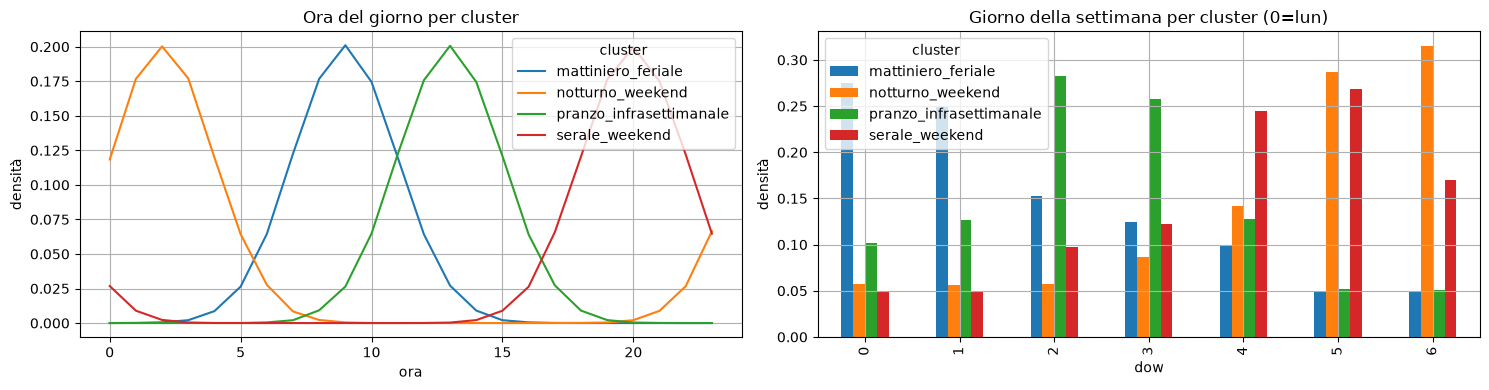

In [7]:
# Distribuzione dell'ora del giorno per cluster (probabilità per ogni cluster)
hour_ct = pd.crosstab(df["hour"], df[CLUSTER], normalize="columns")
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
hour_ct.plot(ax=ax[0])
ax[0].set(title="Ora del giorno per cluster", xlabel="ora", ylabel="densità")
dow_ct = pd.crosstab(df["dow"], df[CLUSTER], normalize="columns")
dow_ct.plot.bar(ax=ax[1])
ax[1].set(title="Giorno della settimana per cluster (0=lun)", xlabel="dow", ylabel="densità")
plt.tight_layout()

,mean,median,std
cluster,,,
mattiniero_feriale,11.99,7.98,12.49
notturno_weekend,12.01,7.94,12.51
pranzo_infrasettimanale,12.13,7.98,12.62
serale_weekend,12.05,7.98,12.56


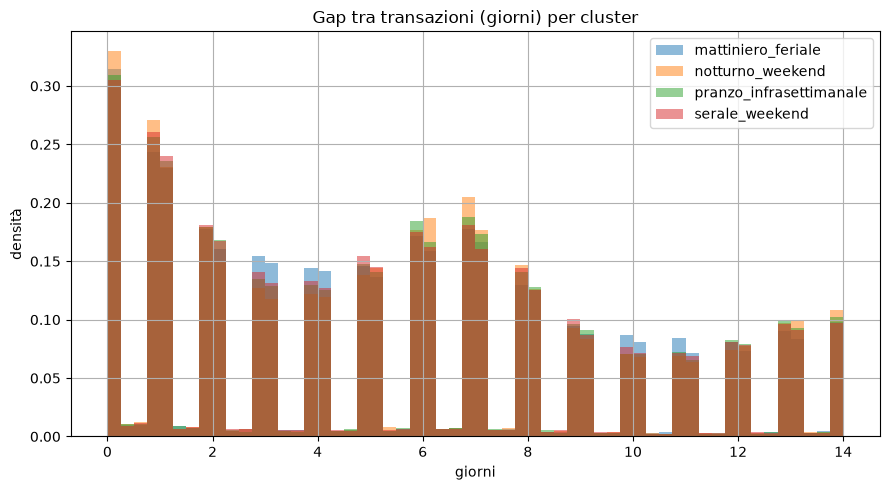

In [8]:
# Gap tra transazioni: emerge dalla concentrazione su pochi giorni/ore
fig, ax = plt.subplots(figsize=(9, 5))
for c in clusters:
    gap = df.loc[df[CLUSTER] == c, "delta_t_days"].dropna()
    ax.hist(gap[gap < 14], bins=56, alpha=0.5, density=True, label=c)
ax.set(title="Gap tra transazioni (giorni) per cluster", xlabel="giorni", ylabel="densità")
ax.legend()
plt.tight_layout()
df.groupby(CLUSTER)["delta_t_days"].agg(["mean", "median", "std"]).round(2)

## 3. Proiezione su feature temporali per cliente

Aggreghiamo ogni cliente nel suo **profilo temporale**: l'istogramma
normalizzato delle 24 ore + quello dei 7 giorni della settimana (31 dimensioni).
Dopo standardizzazione proiettiamo con PCA e t-SNE: i quattro cluster devono
emergere come gruppi distinti.

In [9]:
hour_hist = pd.crosstab(df[CLIENT], df["hour"])
hour_hist = hour_hist.div(hour_hist.sum(axis=1), axis=0).add_prefix("h")
dow_hist = pd.crosstab(df[CLIENT], df["dow"])
dow_hist = dow_hist.div(dow_hist.sum(axis=1), axis=0).add_prefix("d")

feats_time = hour_hist.join(dow_hist).fillna(0.0)
labels = df.groupby(CLIENT)[CLUSTER].first().loc[feats_time.index]
print("Matrice feature temporali per cliente:", feats_time.shape)
feats_time.head()

Matrice feature temporali per cliente: (4000, 31)


,h0,h1,h2,h3,h4,h5,h6,h7,h8,h9,h10,h11,h12,h13,h14,h15,h16,h17,h18,h19,h20,h21,h22,h23,d0,d1,d2,d3,d4,d5,d6
client_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.015385,0.015385,0.092308,0.123077,0.169231,0.169231,0.192308,0.100000,0.053846,0.053846,0.007692,0.007692,0.000000,0.000000,0.000000,0.000000,0.076923,0.084615,0.253846,0.292308,0.146154,0.076923,0.069231
1,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.012048,0.000000,0.036145,0.096386,0.228916,0.180723,0.132530,0.216867,0.060241,0.012048,0.000000,0.024096,0.000000,0.000000,0.000000,0.000000,0.132530,0.072289,0.313253,0.253012,0.132530,0.036145,0.060241
2,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.019802,0.049505,0.158416,0.227723,0.198020,0.158416,0.089109,0.089109,0.009901,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.108911,0.217822,0.336634,0.168317,0.089109,0.029703,0.049505
3,0.007576,0.007576,0.007576,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.007576,0.000000,0.007576,0.015152,0.083333,0.136364,0.196970,0.143939,0.174242,0.151515,0.060606,0.068182,0.053030,0.090909,0.136364,0.242424,0.280303,0.128788
4,0.007634,0.007634,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.015267,0.015267,0.007634,0.038168,0.152672,0.198473,0.137405,0.206107,0.160305,0.053435,0.068702,0.030534,0.083969,0.099237,0.244275,0.290076,0.183206


Varianza spiegata cumulata: [0.426 0.713 0.896 0.906 0.913 0.92  0.927 0.934 0.94  0.946]


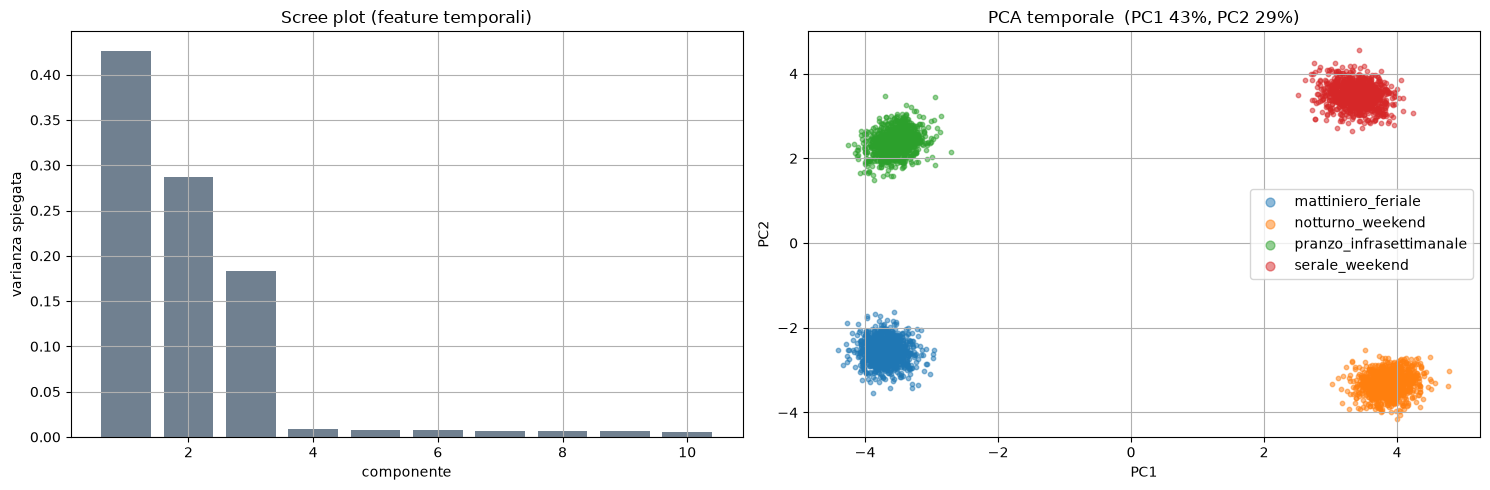

In [10]:
Xt = StandardScaler().fit_transform(feats_time.values)
pca = PCA(n_components=10, random_state=0).fit(Xt)
Xp = pca.transform(Xt)
evr = pca.explained_variance_ratio_
print("Varianza spiegata cumulata:", np.round(np.cumsum(evr), 3))

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].bar(range(1, len(evr) + 1), evr, color="slategray")
ax[0].set(title="Scree plot (feature temporali)", xlabel="componente", ylabel="varianza spiegata")
for c in clusters:
    m = labels.values == c
    ax[1].scatter(Xp[m, 0], Xp[m, 1], s=10, alpha=0.5, label=c)
ax[1].set(title=f"PCA temporale  (PC1 {evr[0]:.0%}, PC2 {evr[1]:.0%})", xlabel="PC1", ylabel="PC2")
ax[1].legend(markerscale=2)
plt.tight_layout()

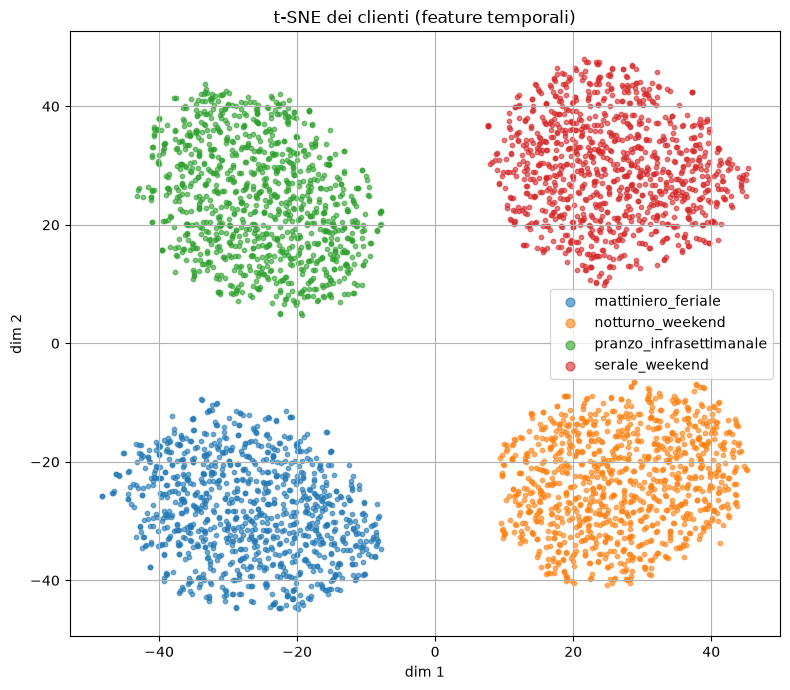

In [11]:
tsne = TSNE(n_components=2, perplexity=30, init="pca", random_state=0)
Xe = tsne.fit_transform(Xt)
fig, ax = plt.subplots(figsize=(8, 7))
for c in clusters:
    m = labels.values == c
    ax.scatter(Xe[m, 0], Xe[m, 1], s=10, alpha=0.6, label=c)
ax.set(title="t-SNE dei clienti (feature temporali)", xlabel="dim 1", ylabel="dim 2")
ax.legend(markerscale=2)
plt.tight_layout()

## 4. Contrasto: feature di valore vs temporali

Ripetiamo la PCA usando solo le feature di **valore** (statistiche su importo +
istogrammi merchant/cocau). Essendo condivise tra cluster, la proiezione
**non** dovrebbe separare le classi — a conferma che l'unico segnale è il tempo.

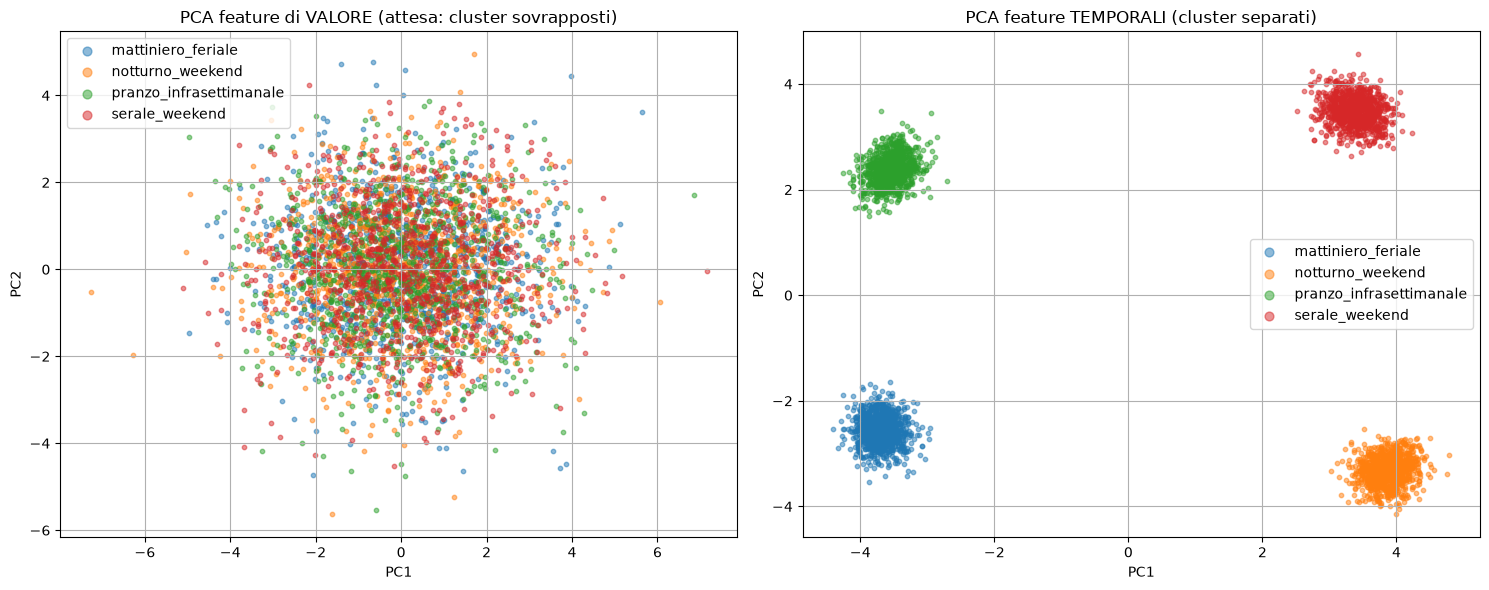

In [12]:
g = df.groupby(CLIENT)
num_feats = pd.DataFrame({
    "amount_mean": g[AMOUNT].mean(),
    "amount_std": g[AMOUNT].std().fillna(0.0),
    "abs_amount_mean": g[AMOUNT].apply(lambda s: s.abs().mean()),
    "frac_negative": g[AMOUNT].apply(lambda s: (s < 0).mean()),
    "n_unique_merchant": g[MERCHANT].nunique(),
    "n_unique_cocau": g[COCAU].nunique(),
})
TOPM = df[MERCHANT].value_counts().head(15).index
TOPC = df[COCAU].value_counts().head(15).index
mh = pd.crosstab(df[CLIENT], df[MERCHANT])[TOPM]
mh = mh.div(mh.sum(axis=1).replace(0, 1), axis=0).add_prefix("m_")
ch = pd.crosstab(df[CLIENT], df[COCAU])[TOPC]
ch = ch.div(ch.sum(axis=1).replace(0, 1), axis=0).add_prefix("c_")
feats_val = num_feats.join(mh).join(ch).fillna(0.0).loc[feats_time.index]

Xv = StandardScaler().fit_transform(feats_val.values)
Xpv = PCA(n_components=2, random_state=0).fit_transform(Xv)

fig, ax = plt.subplots(1, 2, figsize=(15, 6), sharex=False)
for c in clusters:
    m = labels.values == c
    ax[0].scatter(Xpv[m, 0], Xpv[m, 1], s=10, alpha=0.5, label=c)
    ax[1].scatter(Xp[m, 0], Xp[m, 1], s=10, alpha=0.5, label=c)
ax[0].set(title="PCA feature di VALORE (attesa: cluster sovrapposti)", xlabel="PC1", ylabel="PC2")
ax[1].set(title="PCA feature TEMPORALI (cluster separati)", xlabel="PC1", ylabel="PC2")
ax[0].legend(markerscale=2); ax[1].legend(markerscale=2)
plt.tight_layout()

## 5. Conclusioni

* Le variabili di valore (`importo`, `merchant`, `cocau`) sono
  **indistinguibili** tra cluster: medie e distribuzioni coincidono e la PCA
  sulle sole feature di valore mescola le classi — esattamente il controllo
  voluto dall'esperimento.
* Ora-del-giorno e giorno-della-settimana mostrano picchi netti e disgiunti
  per i quattro cluster; il gap tra transazioni ne è una conseguenza.
* PCA e t-SNE sul **profilo temporale** per cliente separano chiaramente le
  quattro classi: è il segnale che un buon encoder time-aware
  (`TimeAwarePositionalEncoding` + datetime encoder) deve recuperare.